## DLA CODE OF CONDUCT V2.0

This Code of Conduct defines the principles governing ethical, transparent, and responsible use of Large Language Models (LLMs), online resources, and peer collaboration in the Deep Learning Applications laboratories. This version of the Code of Conduct was refined via a brainstorming session with **ChatGPT Version 5.2** and subsequently adapted to reflect the specific requirements and values of the DLA laboratories. In that spirit, this Code itself models the transparency it expects from you.

***Our goal is not to restrict innovation, but to ensure integrity, accountability, and genuine learning.***

### 1. Transparency in the Use of LLMs and AI Tools

The use of LLMs and AI-assisted tools is permitted — *but it must be transparent*.

* **Explicit Disclosure:** Clearly state if and how LLMs (e.g., ChatGPT, Copilot, Claude, etc.) were used. This includes code generation, debugging, data analysis, experiment design, report writing, or conceptual clarification.
* **Description of Contribution:** Briefly describe what the tool contributed and how you modified, verified, or extended its output.
* **Acknowledgment of Limitations:** Recognize that LLM outputs may contain errors, biases, or non-optimal solutions. You are responsible for verifying correctness, appropriateness, and academic integrity.

***Using AI does not reduce your responsibility for the final result.***

### 2. Proper Attribution and Documentation

Deep learning builds on existing work — responsibly.

* **Attribution:** Properly cite all external resources, including: Code snippets, Tutorials, Documentation, Datasets, Pretrained models, Research papers, and AI-generated content.
* **Reproducibility:** Clearly document tools, libraries, model versions, hyperparameters, and experimental setups so that your work can be reproduced.
* **Clarity of Modifications:** If you adapt external code, explicitly indicate what you changed and why.

***Transparency is a sign of scientific maturity — not weakness.***

### 3. Collaboration and Individual Responsibility

Discussion is encouraged. Copying is not.

* **Collaborative Learning:** You are encouraged to discuss concepts, debugging strategies, and approaches with classmates.
* **Individual Submission:** Your submitted solution must reflect your own understanding and implementation.
* **No Direct Sharing of Solutions:** Do not share complete solutions, trained models, or reports. Do not submit another person's work — or AI-generated work — as your own without meaningful engagement and proper disclosure.

***If you cannot explain your submission, it is not your submission.***

### 4. Accountability and Academic Integrity

You are responsible for everything you submit. Failure to comply with these guidelines may result in review by the course examination commission and can lead to disciplinary measures in accordance with university regulations.

***Integrity is part of your training as a machine learning practitioner.***

### 5. The Spirit of This Code of Conduct

This course prepares you to work in a field where:

* Reproducibility matters
* Ethical considerations matter
* Transparency matters
* Responsible AI use matters

***The purpose of this Code of Conduct is not surveillance — it is professional formation.***

### TL;DR

Use AI; Don’t let AI use you; Be transparent; Cite everything; Do your own thinking.

***If you can’t explain it, you probably shouldn’t submit it.***

---
---

## Introduction

In this first laboratory we will see a few ways to exploit and adapt pre-trained models to solve new problems. We will start first by downloading and instantiating a new dataset and establishing a stable and reproducible baseline model based on a pre-trained CNN.

---

## Exercise 1 (Warmup): Exploratory Data Analysis and a Stable Baseline

For this laboratory we will work with [The German Traffic Sign Detection Benchmark](https://benchmark.ini.rub.de/) [1]. We will begin, not with *detection*, but with a simpler traffic sign *classification* problem. This has two advantages: (1) the images are *smaller* than in the detection benchmark; and (2) a wrapper for the GTSRB dataset is conveniently included in the `torchvision` library.  

[1] Houben S, Stallkamp J, Salmen J, Schlipsing M, Igel C. Detection of traffic signs in real-world images: The German Traffic Sign Detection Benchmark. In The 2013 International Joint Conference on Neural Networks (IJCNN), 2013.

### Exercise 1.1: Exploratory Data Analysis

A good best practice to adopt in all experimental deep learning projects is thorough *exploratory data analysis*. In this exercise you should instantiate the GTSRB Dataset, inspect some images, and do some statistical analysis of the distribution of data (and metadata). A goal here is to keep an eye out for anything that might be problematic in what is to come.



In [10]:
# Standard imports and aliases.
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision.transforms.v2 as T     # Use transforms v2; much more efficient.
from torchvision.datasets import GTSRB
import pandas as pd
'''
%load_ext autoreload
%autoreload 2
'''

device = 'cuda' if torch.cuda.is_available() else 'cpu'

print(device)

transform = T.Compose([
    T.ToImage(), 
    T.ToDtype(torch.float32, scale=True)
])
# Load the GTSRB dataset.
ds_train = GTSRB(root='_data', split='train', transform=transform, download=True)
ds_test = GTSRB(root='_data', split='test', transform=transform, download=True)

cuda


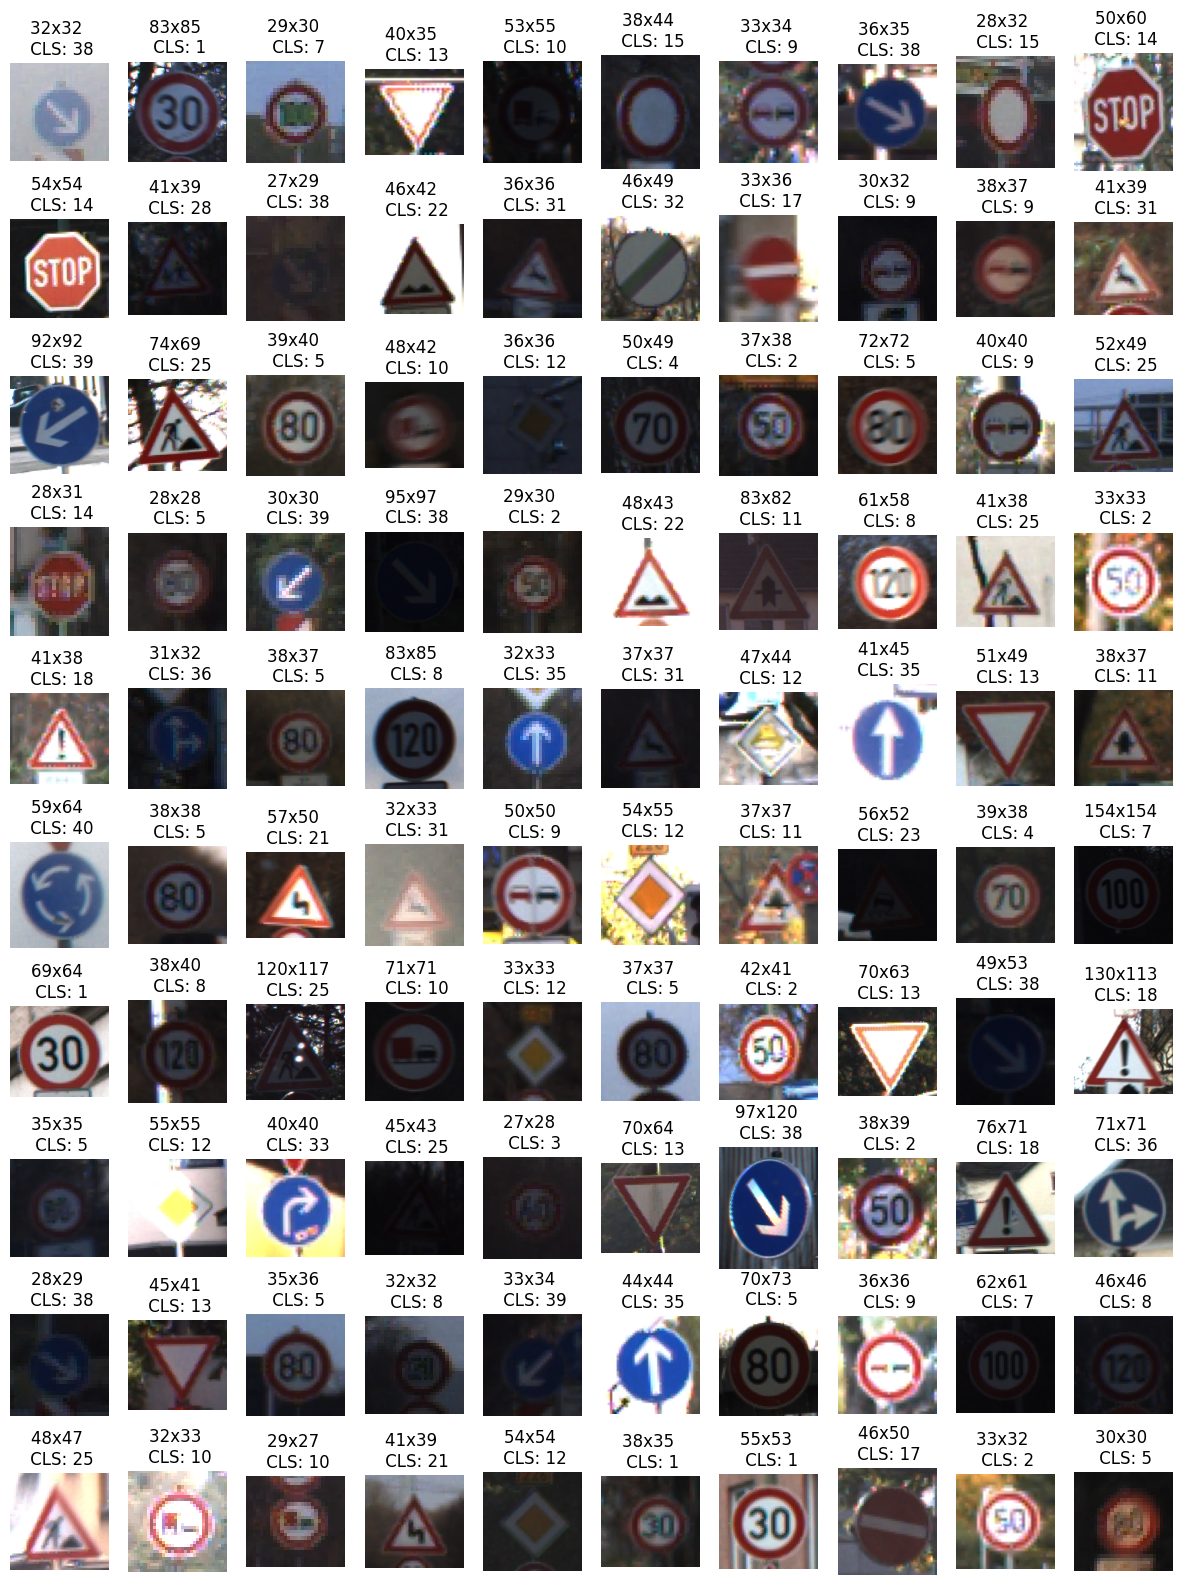

In [11]:
num_samples = 100
# Take random samples and plot them with labels
image_samples = [ds_train[idx] for idx in np.random.choice(len(ds_train), num_samples, replace=False)]

plt.figure(figsize=(15,20))
for (idx, (im, cls)) in enumerate(image_samples):
    plt.subplot(10, 10, idx+1)
    plt.imshow(im.permute([1, 2, 0]))
    height = im.shape[1]
    width = im.shape[2]
    plt.title(f'{width}x{height} \n CLS: {cls}')
    plt.axis('off')


### Should we remove low-resolution images?

In [12]:
df_train = pd.DataFrame([(cls, im.shape[1], im.shape[2]) for (im, cls) in ds_train], columns=['CLASS', 'HEIGHT', 'WIDTH'])
df_train['AREA'] = df_train['HEIGHT'] * df_train['WIDTH']
df_train['AR'] = df_train['WIDTH'] / df_train['HEIGHT']

In [13]:
df_train.describe()

,CLASS,HEIGHT,WIDTH,AREA,AR
count,26640.000000,26640.000000,26640.000000,26640.000000,26640.000000
mean,15.887387,50.365128,50.933784,3118.879167,1.008718
std,12.044099,23.161523,24.373418,3684.970284,0.072100
min,0.000000,25.000000,25.000000,625.000000,0.368132
25%,5.000000,35.000000,35.000000,1190.000000,0.972222
50%,12.000000,43.000000,43.000000,1849.000000,1.000000
75%,25.000000,58.000000,58.000000,3364.000000,1.044444
max,42.000000,225.000000,243.000000,54675.000000,1.417808


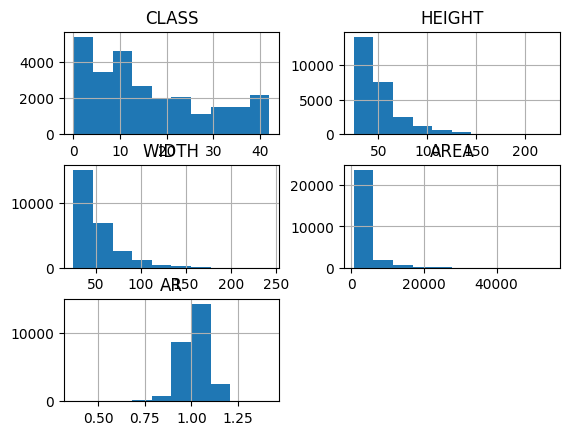

In [14]:
_ = df_train.hist()

97.5th percentile of AREA: 13924.0


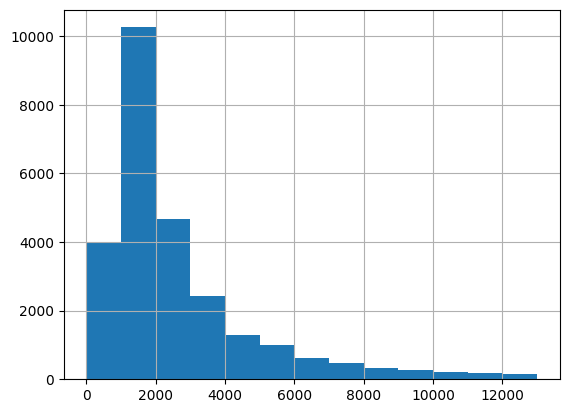

In [15]:
p97_5 = np.percentile(df_train['AREA'], 97.5)
print(f'97.5th percentile of AREA: {p97_5}')

_ = df_train['AREA'].hist(bins = [i for i in range(0, int(p97_5) + 1, 1000)])

Many images have area < 1000 (~ 32x32). Maybe too many to remove them.

In [16]:
# Resize images to 70x70, random crop to 64x64, rescale the images values to [0, 1] and normalize with torchvision ResNet18 normalization values.   
transform = T.Compose([T.Resize(70), T.RandomCrop((64, 64)), T.ToImage(), T.ToDtype(torch.float32, scale=True), T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])
ds_train = GTSRB('_data/', split='train', transform=transform, download=True)
ds_test  = GTSRB('_data/', split='test', transform=transform, download=True)

### Analysis

Deep Learning is very much an *experimental* discipline. Experiments are *nothing* without analysis and interpretation. Be sure to **always** stop and analyze the results of preliminary explorations. Note anything significant and -- importantly -- anything that is going to be relevant for what comes next.

So... In this Markdown cell you should collect and report (using, for the love of God, the *rich markup capabilities of Markdown*) any relevant findings you have made before proceding.

**Important Warning**: This is the **one and only** time I will remind you of the need to provide *analysis* and interpretation of your experimental methodology and results. The responsibility is *yours* to include it elsewhere.


---
### Exercise 1.2: A Stable and Reproducible Baseline

In this exercise you should implement code to use a pretrained network as a *feature extractor* that, instead of *classifying* images in input, should return the *feature representation* from the last layer of the pretrained model before the classifier. These features, extracted from the train set, should be used to train a *classical* model for classification (e.g. an SVM, a Nearest Neighbor, or a Linear Discriminant classifier from Scikit-learn). Evaluate the performance of this baseline model on the features extracted from the test set.

In [17]:
# Your code here.

from torchvision.models import get_model
from torch.utils.data import DataLoader
import torch.nn as nn
from tqdm.notebook import tqdm

# Load ResNet18 and remove final layer to get feature vectors.
model = get_model('resnet18', weights='DEFAULT')
model.fc = nn.Identity() 
model = model.to(device)

# Dataloaders
batch_size = 128
train_loader = DataLoader(ds_train, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(ds_test, batch_size=batch_size, shuffle=False)



# We have to extract features (calculated by the ResNet18) and labels to train and test the Nearest Neighbor classifier.

def retrieve_features_and_labels(loader): 

    features = []
    labels = []

    for images, cls in tqdm(loader):
        images = images.to(device)
        with torch.no_grad():
            features.append(model(images))
        labels.append(cls)

    features_matrix = torch.vstack(features).cpu()
    labels_vector = torch.cat(labels)

    return features_matrix, labels_vector

model.eval()
train_features, train_labels = retrieve_features_and_labels(train_loader)
test_features, test_labels = retrieve_features_and_labels(test_loader)



  0%|          | 0/209 [00:00<?, ?it/s]

  0%|          | 0/99 [00:00<?, ?it/s]

I want to use Nearest Neighbor. I need to know the best k to use, I will use GridSearchCV for it

In [18]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

knn = KNeighborsClassifier()
param_grid = {'n_neighbors': [i for i in range(1,16,2)]}
print(param_grid)
grid_search = GridSearchCV(knn, param_grid, cv=5)
grid_search.fit(train_features, train_labels)
print(f'Best parameter: {grid_search.best_params_}')

{'n_neighbors': [1, 3, 5, 7, 9, 11, 13, 15]}
Best parameter: {'n_neighbors': 1}


<Axes: >

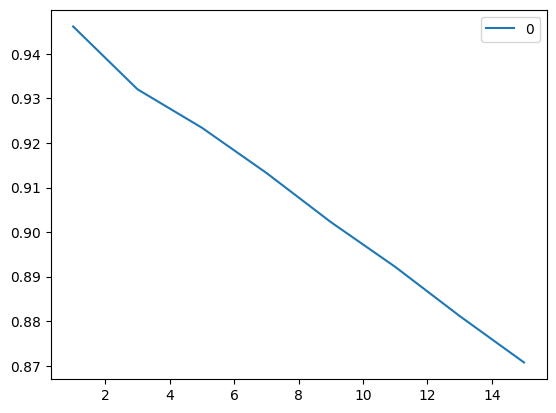

In [19]:
df_results = pd.DataFrame(grid_search.cv_results_['mean_test_score'], index=param_grid['n_neighbors'])
df_results.plot()


Accuracy seems to decrease really fast incrementing k

In [20]:
best_knn = KNeighborsClassifier(n_neighbors=grid_search.best_params_['n_neighbors'])
best_knn.fit(train_features, train_labels)
print(classification_report(best_knn.predict(test_features), test_labels))

              precision    recall  f1-score   support

           0       0.20      0.26      0.22        47
           1       0.39      0.49      0.43       574
           2       0.31      0.35      0.33       663
           3       0.28      0.20      0.24       620
           4       0.36      0.29      0.32       821
           5       0.36      0.31      0.33       734
           6       0.87      0.79      0.83       164
           7       0.35      0.36      0.35       433
           8       0.23      0.21      0.22       493
           9       0.44      0.68      0.54       315
          10       0.73      0.68      0.70       707
          11       0.23      0.31      0.26       311
          12       0.86      0.93      0.89       632
          13       0.94      0.92      0.93       733
          14       0.73      0.94      0.82       210
          15       0.84      0.93      0.89       190
          16       0.71      0.68      0.69       156
          17       0.78    

Test accuracy is way lower than train accuracy, are we overfitting?

Used Gemini 3.0 Pro for the optimization of k nearest neighbor: https://gemini.google.com/share/2e77710e908f


---
### Exercise 1.3: A Fine-tuning Baseline

In this exercise you should try to *improve* on the stable baseline given by the feature extraction + SVM (or whatever) classifier you produced in the previous lecture. To do this, you should *fine-tune* the ResNet-18 (or whatever model you chose) to solve the new classification task.

To do this, you could proceed by:
1. Loading the ResNet-18 (or whatever) model and replacing the final FC layer (the classifier) with a *new* classifier. This could be a single Linear layer, or could be an MLP.
2. Training the resulting model on the GTSRB dataset for a few epochs.
3. Evaluating the resulting performance.

Some things you should probably consider (especially thinking about the *next* exercise):
+ You should be monitoring not only the loss on the training set, but also a *validation* loss on an *independent* validation set. Split the training set into two datasets: one with, say, 80% of the original training samples, and another with the remaining 20%. You can use this smaller set to monitor performance and check for *overfitting*.
+ Maybe the best strategy is to not fine-tune *all* layers, but only the last few. Think about *selectively* fine-tuning layers of the network.
+ Maybe a *single* linear layer isn't the best option for the classifier. Think about using an MLP instead.

Firstly, I have to extract a validation set from the previous training set.

In [21]:
from torch.utils.data import random_split

val_samples = int(0.2 * len(ds_train))
train_samples = len(ds_train) - val_samples

ds_train_final, ds_val = random_split(
    ds_train,
    [train_samples, val_samples],
    generator=torch.Generator().manual_seed(42) # Fix seed for reproducibility
)

train_loader_final = DataLoader(ds_train_final, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(ds_val, batch_size=batch_size, shuffle=False)


Once I have train, validation and test set I create the final model replacing the fc layer with a MLP. I must know the size of the first layer (size of features extracted by resnet-18) and the output layer (number of classes of GTSRB = 43)

In [22]:
# Since we have already extracted the features, we can directly check the shape of them
features_dim = train_features.shape[1]
print(f'Features dimension: {features_dim}')

# We can also check the dimension of input of the final fc layer of ResNet18. 
model = get_model('resnet18', weights='DEFAULT')

n_inputs_fc = model.fc.in_features # Must be equal to the features dimension

print(f'Number of inputs for the final layer: {n_inputs_fc}')


Features dimension: 512
Number of inputs for the final layer: 512


Now that we know the size of first and last layers of MLP, we have to create it and replace the fc layer.

In [23]:
from torch import nn
n_classes = 43
 
mlp = nn.Sequential(
    nn.Linear(features_dim, 256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, n_classes)
)

model.fc = mlp
model = model.to(device)

In [24]:
# Check the output shape of the model with a random input
false_input = torch.randn(1, 3, 224, 224) 
false_input = false_input.to(device)
output = model(false_input)
print(output.shape)

torch.Size([1, 43])


Now we can train the model. I am going to only train the last 2 layers (layer3, layer4) of resnet and, of course, the mlp head. I will use Cross Entropy Loss and Adam as the optimizer

In [25]:
# Freeze layer1 and layer2 of ResNet18
for param in model.layer1.parameters():
    param.requires_grad = False
for param in model.layer2.parameters():
    param.requires_grad = False

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)    


In [26]:
from library import train_epoch, evaluate_model


# Training and validating loop
num_epochs = 6
train_losses = []
val_losses = []
val_accs = []

for epoch in range(num_epochs):
    
    epoch_train_loss = train_epoch(model, train_loader_final, criterion, optimizer, device)

    epoch_val_loss, epoch_val_acc = evaluate_model(model, val_loader, criterion, device)

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    val_accs.append(epoch_val_acc)


<Axes: >

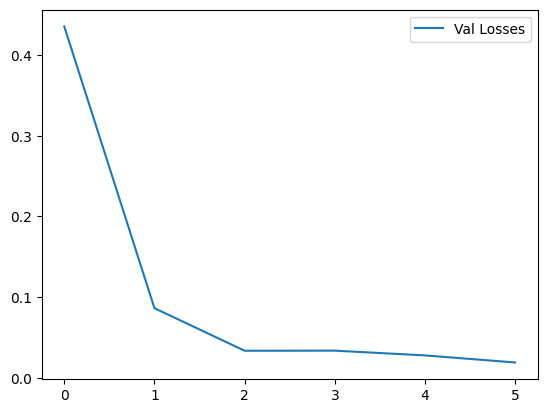

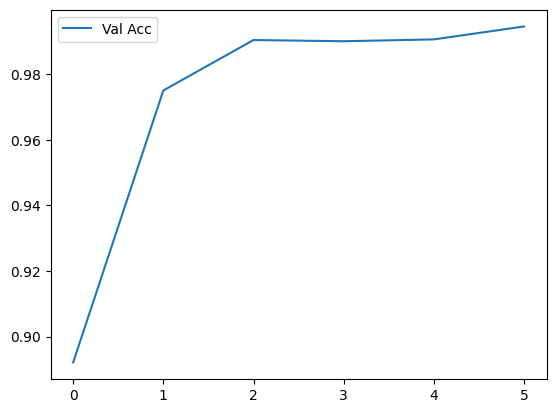

In [27]:
df_losses = pd.DataFrame(data = {"Train Losses": train_losses, "Val Losses": val_losses})
df_losses.plot()

df_acc = pd.DataFrame(data = {"Val Acc": val_accs})
df_acc.plot()


 It seems that we reached the cap, let's see how it performs on test set

In [28]:
# Test loop
test_loss, test_acc = evaluate_model(model, val_loader, criterion, device)

print("Test Loss: " + str(test_loss))
print("Test Accuracy: " + str(test_acc))

Test Loss: 0.021871856097747257
Test Accuracy: 0.9930555555555556


---
---
## Exercise 2: Pipeline Consolidation

Consolidate your implementation. When building applications based asd on Deep Learning, you will inevitably need to run many, many experiments. So, it is *always* a good idea to engineer a reproducible pipeline that allows you to run (and re-run) experiments with different hyperparameters. In this exercise you should do exactly this: engineer a deep learning pipeline that encapsulates (at least) training and evaluation so that you can easily and reproducibly run multiple experiments and compare the results.

Some things to think about when engineering this pipeline:
- **Model and Loss (and maybe Optimizer) Abstraction**: An important variable in training deep models is the model (obviously), the loss (somewhat less obvious), and the optimizer (less obvious) used during training. Your pipeline should probably be able to adapt to these changing configurations.
- **Configuration management**: Instead of global variables specializing each cell, thread a configuration object through your code (or use a singleton). If you are planning to use an IDE and not this notebook for the lab, you might consider using a configuration management library like [OmegaConf](https://omegaconf.readthedocs.io/en/2.3_branch/) which will help instrument your code so that you can pass configuration overrides via command line arguments.
- **Logging**: You will invariably need to run and compare multiple experiments. Instrument your code for monitoring training. Good options are [Tensorboard](https://docs.pytorch.org/tutorials/recipes/recipes/tensorboard_with_pytorch.html) or [Weights and Biases (WandB)](https://wandb.ai/site/). My PhD students seem to overwhelmingly prefer Weights and Biases. The configuration parameters should be used to facilitate distinguishing and comparing multiple runs with multiple hyperparameters.

### Let's start creating our configuration with OmegaConf

In [29]:
from omegaconf import OmegaConf

# Create configuration with OmegaConf
config_dict = {
    "experiment_name" : "config_trial",
    "hyperparameters" : {
        "epochs" : 10,
        "batch_size" : 128,
        "learning_rate" : 1e-04,
        "optimizer" : "adam",
        "loss_function" : "cross_entropy"
    },
    "model" : "resnet18_MLP"
}

config = OmegaConf.create(config_dict)


In [30]:
import wandb
from library import create_resnet18_MLP
                
def pipeline(cfg):

    wandb.init(
        project = "first notebook DLA2026",
        name = cfg.experiment_name,
        config = cfg
    )

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Take Datasets
    ds_train_temp = GTSRB(root='_data', split='train', transform=transform, download=True)
    ds_test = GTSRB(root='_data', split='test', transform=transform, download=True)

    batch_size = cfg.hyperparameters.batch_size

    # Make validation set
    val_size= int(0.2 * len(ds_train_temp))
    train_size = len(ds_train_temp) - val_size

    ds_train, ds_val = random_split(
        ds_train_temp,
        [train_size, val_size],
        generator=torch.Generator().manual_seed(42) # Fix seed for reproducibility
    )

    # Make DataLoaders
    train_loader = DataLoader(ds_train, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(ds_val, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(ds_test, batch_size=batch_size, shuffle= False)

    if cfg.model == "resnet18_MLP":
        model = create_resnet18_MLP(n_outputs=43)
    else:
        raise ValueError(f"Model {cfg.model} not supported")

    if cfg.hyperparameters.loss_function == "cross_entropy":
        criterion = nn.CrossEntropyLoss()
    else:
        raise ValueError(f"Loss {cfg.hyperparameters.loss_function} not supported")

    if cfg.hyperparameters.optimizer == "adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=cfg.hyperparameters.learning_rate)
    else:
        raise ValueError(f"Optimizer {cfg.hyperparameters.optimizer} not supported")


    for i in range (cfg.hyperparameters.epochs):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)

        val_loss, val_acc = evaluate_model(model, val_loader, criterion, device)

        wandb.log({
            "epoch": i + 1,
            "train/loss": train_loss,
            "train/accuracy" : train_acc,
            "val/loss" : val_loss,
            "val/accuracy" : val_acc
        })

    test_loss, test_acc = evaluate_model(model, test_loader, criterion, device)

    wandb.summary["test_loss"] = test_loss
    wandb.summary["test_accuracy"] = test_acc
    wandb.finish()
    print(f"Loss: {test_loss} | Accuracy: {test_acc}")

pipeline(config)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/stefano/.netrc.
wandb: Currently logged in as: stefanomagnolfiunifi (stefanomagnolfiunifi-universit-di-firenze) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


epoch,▁▂▃▃▄▅▆▆▇█
train/accuracy,▁█████████
train/loss,█▁▁▁▁▁▁▁▁▁
val/accuracy,▁▇▅█▆████▇
val/loss,█▂▃▁▂▁▁▁▁▂
epoch,10
test_accuracy,0.9639
test_loss,0.13822
train/accuracy,0.99892
train/loss,0.00463
val/accuracy,0.99587


Loss: 0.1382232482340821 | Accuracy: 0.963895486935867



---
---
## Exercise 3: Choose your Own Adventure

As promised, you should choose **one** of the following exercises to work. Well, at *least* one. If you want to do them all, that is also OK! 


---
### Exercise 3.2: Retrieval as Training-free Classification (a bit harder)

In this exercise you will treat the problem of classifying road signs as a type of retrieval problem. By doing so, will will avoid the need to perform extensive fine-tuning of our model and will instead count of the good *representations* provided by massively pretrained models.

How, you ask? In this exercise you should treat the training set as a *gallery* of indexed image descriptors and the test set as a set of *query* descriptors. You could proceed in this way:

1. **Implement** a generic *feature extraction* function that, given a model and a dataloader, will extract the feature representations of all images in the dataloader. You should make this function generic because you will of course want to try *multiple* pretrained backbones in order to pick the best one.
2. **Implement** a function to *query* the gallery using all extracted extracted from the test set. The results of this should be a *ranking* of all gallery images in terms of similarity with each test image. You should think carefully about how to compute this *similarity* score and how to compute it efficiently.
3. **Evaluate** the retrieval performance on each of the 43 classes in the GTSRB dataset using the similarity scores. This could be done using precision recall curves, average precision/recall, or other metrics.

Wait, this isn't a classifier... Well, no. But, if you use the above *pipeline* to select the best feature extraction pipeline, you can then implement a **Nearest-Mean Classifier (NMC)**: compute the *mean* feature representation of all training images for each class and *classify* test images based on which mean is **nearest** to it.

**Why choose this exercise?** To learn how to make the most out of pretrained feature extraction backbones, how to evaluate different types of learning systems (retrieval in this case), and to familiarize yourself with similarity-based classification which is extensively used in multimodal models like CLIP.

### I want to use resnet18, efficient-net-b0 and ViT-b-16 as backbones

In [31]:
resnet = get_model('resnet18', weights = "DEFAULT")

efficient_net = get_model('efficientnet_b0', weights = "DEFAULT")

vit = get_model('vit_b_16', weights = "DEFAULT")

train_loader = DataLoader(ds_train, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(ds_val, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(ds_test, batch_size=batch_size, shuffle= False)

In [32]:
from library import extract_features, query_gallery, evaluate_retrieval
import torch.nn.functional as F

def retrieval_pipeline(model, train_loader, val_loader, device, normalize = True):

    train_features_matrix, train_labels = extract_features(model, train_loader, device)

    val_features_matrix, val_labels = extract_features(model, val_loader, device)

    similarity_matrix = query_gallery(train_features_matrix, val_features_matrix, normalize)

    return evaluate_retrieval(similarity_matrix, train_labels, val_labels)

mAP_resnet, mAP_resnet_per_class = retrieval_pipeline(resnet, train_loader, val_loader, device)
mAP_efficientnet, mAP_efficientnet_per_class = retrieval_pipeline(efficient_net, train_loader, val_loader, device)

### For resnet-18 and efficient-net-b0 the same transform can be used. Instead, ViT-b-16 expects 224x224 images and therefore a resize is needed

In [33]:
transform = T.Compose([T.Resize(70), T.RandomCrop((64, 64)), T.Resize((224, 224), interpolation=T.InterpolationMode.BILINEAR), T.ToImage(), T.ToDtype(torch.float32, scale=True), T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])

ds_train_vit_temp = GTSRB(root = "_data", split = "train", transform=transform, download=True)
ds_test_vit = GTSRB(root = "_data", split = "test", transform=transform, download=True)

# Get data loaders
val_size= int(0.2 * len(ds_train_vit_temp))
train_size = len(ds_train_vit_temp) - val_size

ds_train_vit, ds_train_vit = random_split(
    ds_train_vit_temp,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42) 
)

train_loader_vit = DataLoader(ds_train_vit, batch_size=batch_size, shuffle=True)
val_loader_vit = DataLoader(ds_train_vit, batch_size=batch_size, shuffle=False)
test_loader_vit = DataLoader(ds_test_vit, batch_size=batch_size, shuffle= False)

mAP_vit, mAP_vit_per_class = retrieval_pipeline(vit, train_loader_vit, val_loader_vit, device)

print(f"RESNET: mAP total: {mAP_resnet}, mAP per class: {mAP_resnet_per_class}")
print(f"EFFICIENT NET: mAP total: {mAP_efficientnet}, mAP per class: {mAP_efficientnet_per_class}")
print(f"VIT: mAP total: {mAP_vit}, mAP per class: {mAP_vit_per_class}")


RESNET: mAP total: 0.2068819133104668, mAP per class: [(0, 0.1196), (1, 0.1952), (2, 0.2001), (3, 0.126), (4, 0.156), (5, 0.1692), (6, 0.444), (7, 0.1218), (8, 0.1359), (9, 0.1456), (10, 0.1928), (11, 0.1762), (12, 0.2854), (13, 0.3809), (14, 0.6352), (15, 0.3333), (16, 0.1562), (17, 0.4324), (18, 0.2157), (19, 0.1295), (20, 0.1205), (21, 0.1472), (22, 0.1009), (23, 0.1327), (24, 0.1658), (25, 0.1657), (26, 0.1492), (27, 0.1238), (28, 0.1178), (29, 0.1144), (30, 0.1434), (31, 0.1752), (32, 0.3537), (33, 0.1306), (34, 0.1331), (35, 0.1881), (36, 0.1128), (37, 0.1239), (38, 0.2377), (39, 0.1196), (40, 0.1388), (41, 0.2295), (42, 0.2131)]
EFFICIENT NET: mAP total: 0.2190355693593831, mAP per class: [(0, 0.1216), (1, 0.1887), (2, 0.2189), (3, 0.1209), (4, 0.1538), (5, 0.1597), (6, 0.3788), (7, 0.1311), (8, 0.1172), (9, 0.2032), (10, 0.1942), (11, 0.1946), (12, 0.4895), (13, 0.3766), (14, 0.5766), (15, 0.485), (16, 0.2471), (17, 0.2964), (18, 0.2246), (19, 0.1265), (20, 0.1151), (21, 0.1357

### Results are not promising at all. Let's try not to normalize matrixes before similarity matrix calculation

In [34]:
mAP_resnet, mAP_resnet_per_class = retrieval_pipeline(resnet, train_loader, val_loader, device, False)
mAP_efficientnet, mAP_efficientnet_per_class = retrieval_pipeline(efficient_net, train_loader, val_loader, device, False)
mAP_vit, mAP_vit_per_class = retrieval_pipeline(vit, train_loader_vit, val_loader_vit, device, False)

print(f"RESNET: mAP total: {mAP_resnet}, mAP per class: {mAP_resnet_per_class}")
print(f"EFFICIENT NET: mAP total: {mAP_efficientnet}, mAP per class: {mAP_efficientnet_per_class}")
print(f"VIT: mAP total: {mAP_vit}, mAP per class: {mAP_vit_per_class}")

RESNET: mAP total: 0.12904717974975302, mAP per class: [(0, 0.026), (1, 0.1952), (2, 0.2217), (3, 0.0714), (4, 0.1285), (5, 0.0998), (6, 0.1142), (7, 0.0603), (8, 0.069), (9, 0.081), (10, 0.108), (11, 0.1938), (12, 0.1242), (13, 0.2075), (14, 0.3757), (15, 0.0789), (16, 0.0449), (17, 0.3086), (18, 0.2221), (19, 0.0644), (20, 0.0226), (21, 0.0761), (22, 0.0479), (23, 0.0859), (24, 0.0406), (25, 0.116), (26, 0.0522), (27, 0.0327), (28, 0.0508), (29, 0.0417), (30, 0.0498), (31, 0.0579), (32, 0.2516), (33, 0.0901), (34, 0.0939), (35, 0.1024), (36, 0.0522), (37, 0.0354), (38, 0.1238), (39, 0.0452), (40, 0.1251), (41, 0.175), (42, 0.0563)]
EFFICIENT NET: mAP total: 0.19599637882481807, mAP per class: [(0, 0.0811), (1, 0.2003), (2, 0.2036), (3, 0.1134), (4, 0.1406), (5, 0.145), (6, 0.2289), (7, 0.1077), (8, 0.0868), (9, 0.1892), (10, 0.2051), (11, 0.1878), (12, 0.4468), (13, 0.3255), (14, 0.4587), (15, 0.4839), (16, 0.2636), (17, 0.2482), (18, 0.2222), (19, 0.0826), (20, 0.1019), (21, 0.1013)

### Even worse... But since efficient net seems to be the least worse, we try to implement NMC with it.

In [35]:
from library import NMC_test, NMC_train

train_features_matrix, train_labels = extract_features(model, train_loader, device)

test_features_matrix, test_labels = extract_features(model, test_loader, device)

mean_matrix = NMC_train(train_features_matrix, train_labels)

predictions = NMC_test(mean_matrix, test_features_matrix)

In [36]:
predictions

tensor([16,  1, 38,  ...,  6,  7, 10])

In [37]:
test_labels

tensor([16,  1, 38,  ...,  6,  7, 10])

In [38]:
from sklearn.metrics import average_precision_score
report = classification_report(predictions, test_labels)
print(f'report: {report}')

report:               precision    recall  f1-score   support

           0       0.98      0.31      0.47       190
           1       0.82      0.91      0.86       654
           2       0.82      0.86      0.84       716
           3       0.75      0.94      0.84       361
           4       0.87      0.96      0.91       596
           5       0.80      0.84      0.82       599
           6       0.89      0.98      0.93       137
           7       0.94      0.88      0.91       483
           8       0.82      0.91      0.86       402
           9       0.91      1.00      0.95       437
          10       0.92      1.00      0.96       606
          11       0.69      1.00      0.82       289
          12       0.93      1.00      0.96       639
          13       0.98      1.00      0.99       710
          14       0.91      0.98      0.95       251
          15       0.99      0.97      0.98       213
          16       1.00      0.83      0.91       180
          17       

# At the end of the day it performs relatively well

Used Gemini 3.0 Pro to understand better the task: https://gemini.google.com/share/6d634a3a23ca

---
---